In [1]:
!pip install datasets pycddlib umap-learn dask dask-expr cvxopt seaborn plotly --break-system-packages

  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached pycddlib-3.0.2.tar.gz (31 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached dask-2026.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached dask_expr-2.0.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached cvxopt-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (43 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pyarrow-23.0.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using c

In [2]:
import os
from datasets import load_dataset
from datasets import Dataset
from collections import Counter, defaultdict
from tqdm.auto import tqdm

import pandas as pd
pd.set_option("display.max_rows", None)

import random
import numpy as np

from numba import jit

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report

from scipy.spatial import ConvexHull

import polytope as pc

import cdd

from umap import UMAP

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset hat 473800776 Zeilen und die Spalten: 'vertices', 'vertex_count', 'facet_count', 'point_count', 'dual_point_count', 'h11', 'h12', 'euler_characteristic'.

In [3]:
# Do this only once!
dataset = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
)
print(dataset)

Dataset({
    features: ['vertices', 'vertex_count', 'facet_count', 'point_count', 'dual_point_count', 'h11', 'h12', 'euler_characteristic'],
    num_rows: 473800776
})


# A Symmetric Entropy Ridge in Hodge Space for 4D Reflexive Polytopes

## Do the following cell only once!

In [41]:
# =========================
# PARAMETERS
# =========================
batch_size = 100_000

# Falls dein HuggingFace-Dataset anders heißt, hier anpassen:
# z.B. ds4d oder dataset["train"]
ds = dataset

rows = len(ds)
print(f"Total rows: {rows:,}")

# =========================
# ACCUMULATORS
# =========================
# Global counts in (s,d)
counts_sd = Counter()

# Conditional counts for each vertex_count v:
# counts_vsd[v] is a Counter over (s,d)
counts_vsd = defaultdict(Counter)

# Optional: marginal count per vertex_count
counts_v = Counter()

# =========================
# MAIN LOOP
# =========================
for start in tqdm(range(0, rows, batch_size), desc="Processing batches"):
    end = min(start + batch_size, rows)

    batch = ds.select(range(start, end)).to_pandas()

    # Keep only needed columns
    batch = batch[["vertex_count", "h11", "h12"]].copy()

    # Derived coordinates
    batch["s"] = batch["h11"] + batch["h12"]
    batch["d"] = batch["h11"] - batch["h12"]

    # ---------
    # Global (s,d) counts
    # ---------
    sd_counts_batch = batch.groupby(["s", "d"]).size()
    for (s, d), c in sd_counts_batch.items():
        counts_sd[(int(s), int(d))] += int(c)

    # ---------
    # Conditional counts by vertex_count
    # ---------
    vsd_counts_batch = batch.groupby(["vertex_count", "s", "d"]).size()
    for (v, s, d), c in vsd_counts_batch.items():
        counts_vsd[int(v)][(int(s), int(d))] += int(c)
        counts_v[int(v)] += int(c)

print("Done.")
print(f"Unique (s,d) states globally: {len(counts_sd):,}")
print(f"Number of vertex_count slices: {len(counts_vsd):,}")

# =========================
# CONVERT TO DATAFRAMES
# =========================
df_sd = pd.DataFrame(
    [(s, d, c, np.log(c)) for (s, d), c in counts_sd.items()],
    columns=["s", "d", "count", "log_count"]
).sort_values(["s", "d"]).reset_index(drop=True)

df_vsd_rows = []
for v, counter in counts_vsd.items():
    for (s, d), c in counter.items():
        df_vsd_rows.append((v, s, d, c, np.log(c)))

df_vsd = pd.DataFrame(
    df_vsd_rows,
    columns=["vertex_count", "s", "d", "count", "log_count"]
).sort_values(["vertex_count", "s", "d"]).reset_index(drop=True)

df_v = pd.DataFrame(
    [(v, c) for v, c in counts_v.items()],
    columns=["vertex_count", "count"]
).sort_values("vertex_count").reset_index(drop=True)

print("\nGlobal (s,d) table:")
display(df_sd.head())

print("\nConditional (v,s,d) table:")
display(df_vsd.head())

print("\nVertex-count totals:")
display(df_v.head())

# =========================
# SAVE RESULTS
# =========================
df_sd.to_parquet("counts_sd_4d_reflexive.parquet", index=False)
df_vsd.to_parquet("counts_vsd_4d_reflexive.parquet", index=False)
df_v.to_parquet("counts_v_4d_reflexive.parquet", index=False)

print("\nSaved:")
print("- counts_sd_4d_reflexive.parquet")
print("- counts_vsd_4d_reflexive.parquet")
print("- counts_v_4d_reflexive.parquet")

Total rows: 473,800,776


Processing batches: 100%|██████████| 4739/4739 [22:23<00:00,  3.53it/s]


Done.
Unique (s,d) states globally: 30,108
Number of vertex_count slices: 30

Global (s,d) table:


,s,d,count,log_count
0,22,-20,1,0.0
1,22,20,1,0.0
2,25,-15,1,0.0
3,25,15,1,0.0
4,26,-12,1,0.0



Conditional (v,s,d) table:


,vertex_count,s,d,count,log_count
0,5,22,-20,1,0.0
1,5,22,20,1,0.0
2,5,30,-12,1,0.0
3,5,30,12,1,0.0
4,5,32,-6,1,0.0



Vertex-count totals:


,vertex_count,count
0,5,1561
1,6,24189
2,7,177446
3,8,834638
4,9,2867955



Saved:
- counts_sd_4d_reflexive.parquet
- counts_vsd_4d_reflexive.parquet
- counts_v_4d_reflexive.parquet


## Load the data (created once by the cell above)

In [4]:
# =========================
# FILE PATHS (ggf. anpassen)
# =========================
file_sd  = "counts_sd_4d_reflexive.parquet"
file_vsd = "counts_vsd_4d_reflexive.parquet"
file_v   = "counts_v_4d_reflexive.parquet"

# =========================
# EXISTENZ CHECK
# =========================
for f in [file_sd, file_vsd, file_v]:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")

print("All parquet files found.")

# =========================
# LOAD
# =========================
df_sd  = pd.read_parquet(file_sd)
df_vsd = pd.read_parquet(file_vsd)
df_v   = pd.read_parquet(file_v)

# =========================
# BASIC INFO
# =========================
print("\nShapes:")
print("df_sd :", df_sd.shape)
print("df_vsd:", df_vsd.shape)
print("df_v  :", df_v.shape)

print("\nSample df_sd:")
display(df_sd.head())

print("\nSample df_vsd:")
display(df_vsd.head())

print("\nSample df_v:")
display(df_v.head())

All parquet files found.

Shapes:
df_sd : (30108, 4)
df_vsd: (229329, 5)
df_v  : (30, 2)

Sample df_sd:


,s,d,count,log_count
0,22,-20,1,0.0
1,22,20,1,0.0
2,25,-15,1,0.0
3,25,15,1,0.0
4,26,-12,1,0.0



Sample df_vsd:


,vertex_count,s,d,count,log_count
0,5,22,-20,1,0.0
1,5,22,20,1,0.0
2,5,30,-12,1,0.0
3,5,30,12,1,0.0
4,5,32,-6,1,0.0



Sample df_v:


,vertex_count,count
0,5,1561
1,6,24189
2,7,177446
3,8,834638
4,9,2867955


In [5]:
df_sd.shape, df_vsd.shape, df_v.shape
df_sd.sort_values("count", ascending=False).head(20)

,s,d,count,log_count
815,54,0,910113,13.721324
636,50,0,877191,13.684480
722,52,0,875275,13.682293
816,54,2,861439,13.666360
814,54,-2,861439,13.666360
910,56,0,856560,13.660680
723,52,2,841741,13.643228
721,52,-2,841741,13.643228
1008,58,0,841586,13.643043
720,52,-4,838090,13.638881


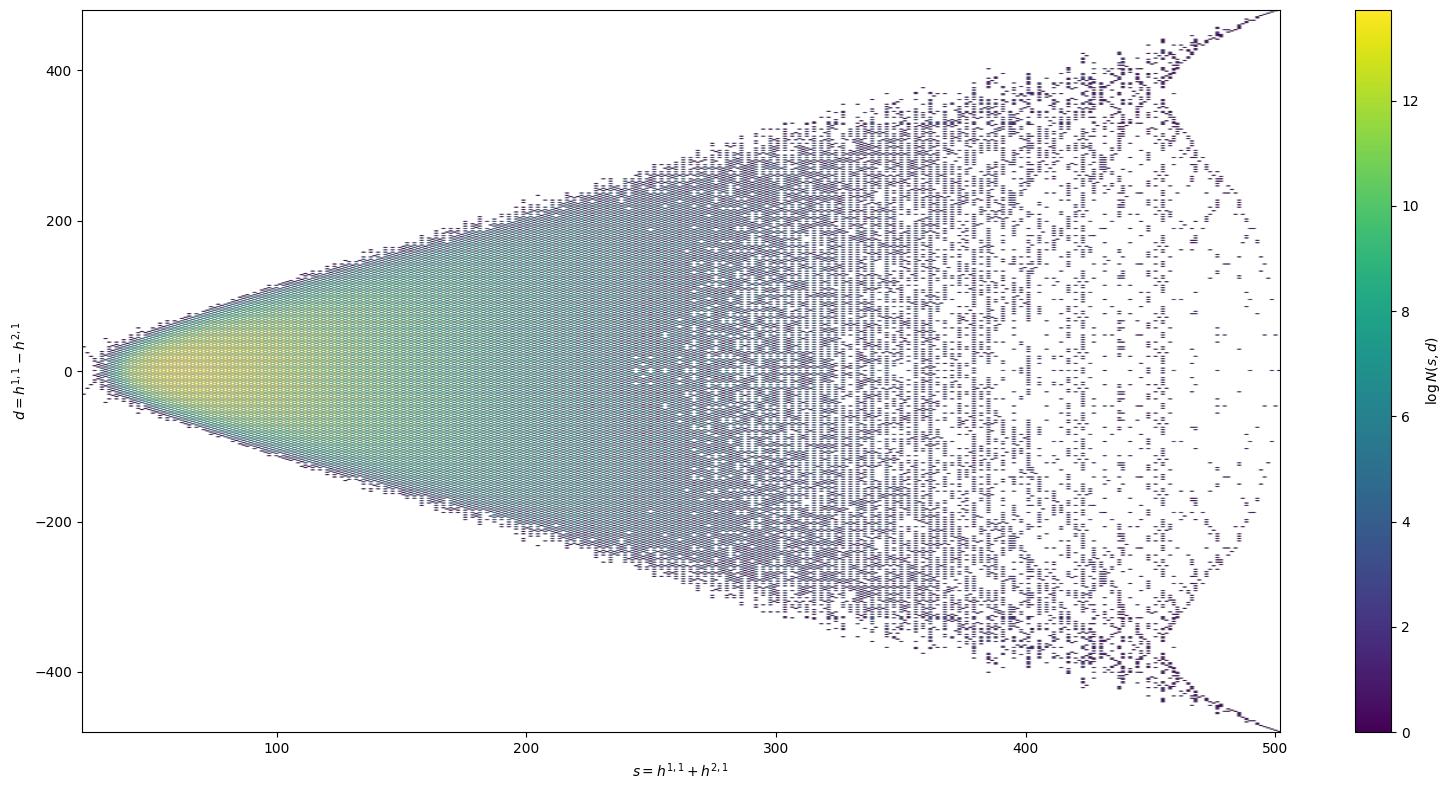

Ridge table:


,s,d_peak,count_peak,log_count_peak
0,22,-20,1,0.000000
1,25,-15,1,0.000000
2,26,-12,1,0.000000
3,28,0,3,1.098612
4,29,-3,3,1.098612
5,30,0,99,4.595120
6,31,-3,22,3.091042
7,32,0,768,6.643790
8,33,-3,553,6.315358
9,34,0,6258,8.741616


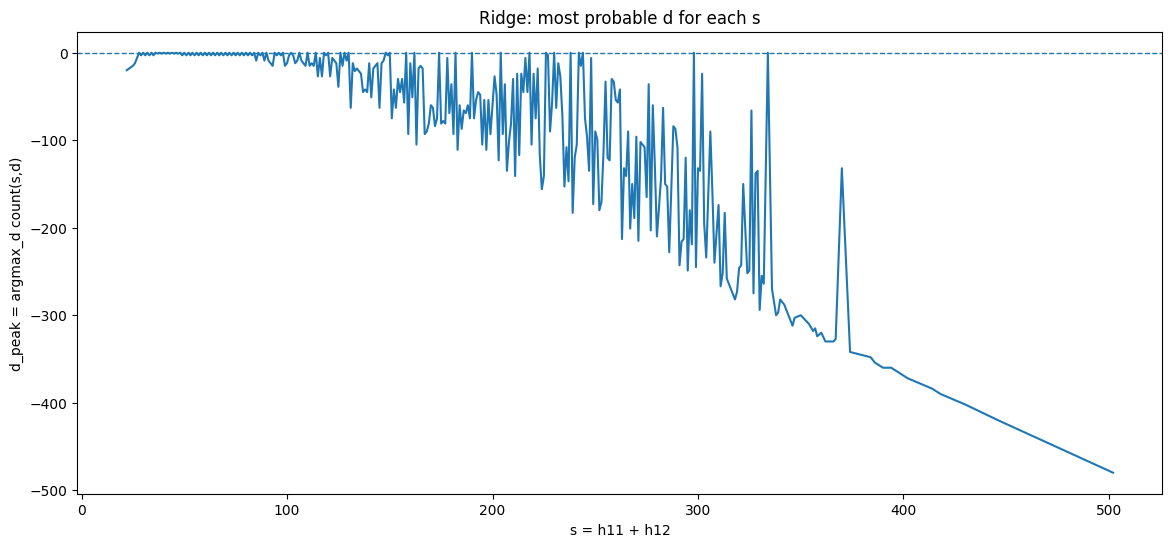

Width table:


,s,total_count,d_mean,d_std,d_mode,count_mode,support_size
0,22,2.0,0.0,20.000000,-20.0,1.0,2.0
1,25,2.0,0.0,15.000000,-15.0,1.0,2.0
2,26,2.0,0.0,12.000000,-12.0,1.0,2.0
3,28,11.0,0.0,6.660603,0.0,3.0,7.0
4,29,12.0,0.0,5.000000,-3.0,3.0,6.0
5,30,345.0,0.0,5.154989,0.0,99.0,17.0
6,31,82.0,0.0,6.958063,-3.0,22.0,12.0
7,32,4152.0,0.0,5.469129,0.0,768.0,23.0
8,33,2710.0,0.0,5.581400,-3.0,553.0,20.0
9,34,37864.0,0.0,5.616447,0.0,6258.0,25.0


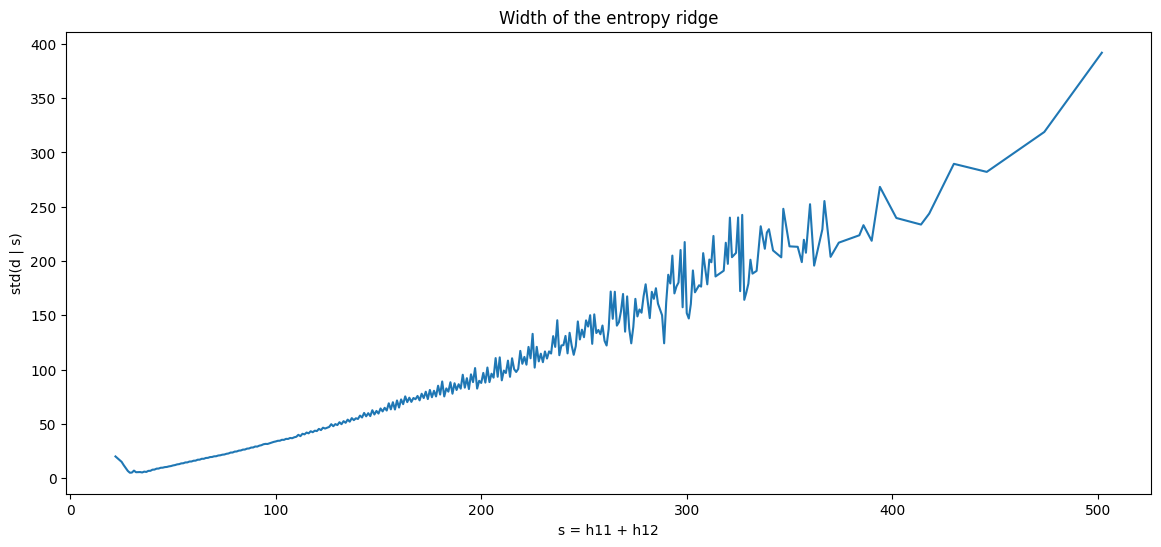

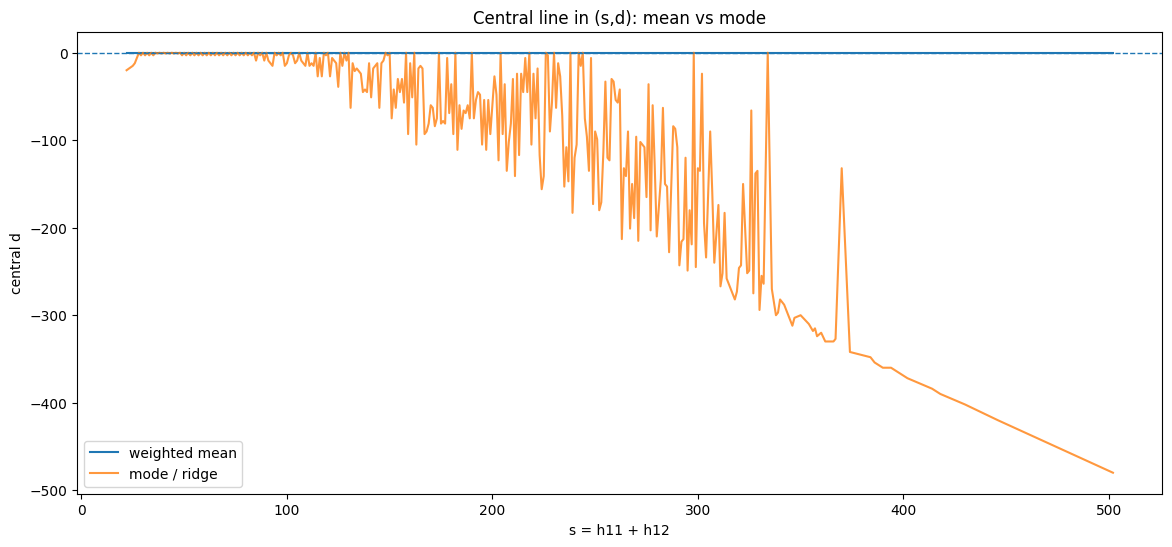

In [6]:
# =========================
# 1) GLOBAL HEATMAP MATRIX
# =========================
pivot_sd = df_sd.pivot(index="d", columns="s", values="log_count").sort_index()

plt.figure(figsize=(16, 8))
im = plt.imshow(
    pivot_sd,
    aspect="auto",
    origin="lower",
    extent=[
        pivot_sd.columns.min(), pivot_sd.columns.max(),
        pivot_sd.index.min(), pivot_sd.index.max()
    ]
)
plt.colorbar(im, label=r"$\log N(s,d)$")
plt.xlabel(r"$s = h^{1,1} + h^{2,1}$")
plt.ylabel(r"$d = h^{1,1} - h^{2,1}$")
plt.tight_layout()
plt.savefig("heatmap_sd.png", dpi=300, bbox_inches="tight")

plt.show()

# =========================
# 2) RIDGE EXTRACTION
# For each s, pick d with maximal count
# =========================
ridge_idx = df_sd.groupby("s")["count"].idxmax()
df_ridge = df_sd.loc[ridge_idx].sort_values("s").reset_index(drop=True)
df_ridge = df_ridge.rename(columns={"d": "d_peak", "count": "count_peak", "log_count": "log_count_peak"})

print("Ridge table:")
display(df_ridge.head(20))

plt.figure(figsize=(14, 6))
plt.plot(df_ridge["s"], df_ridge["d_peak"])
plt.axhline(0, linewidth=1, linestyle="--")
plt.xlabel("s = h11 + h12")
plt.ylabel("d_peak = argmax_d count(s,d)")
plt.title("Ridge: most probable d for each s")
plt.show()

# =========================
# 3) WIDTH AROUND RIDGE
# For each s, compute weighted mean and std in d
# =========================
def weighted_stats(group):
    d = group["d"].to_numpy(dtype=float)
    w = group["count"].to_numpy(dtype=float)

    wsum = w.sum()
    mean = (w * d).sum() / wsum
    var = (w * (d - mean)**2).sum() / wsum
    std = np.sqrt(var)

    # modal value
    i = np.argmax(w)
    d_mode = d[i]
    count_mode = w[i]

    return pd.Series({
        "total_count": wsum,
        "d_mean": mean,
        "d_std": std,
        "d_mode": d_mode,
        "count_mode": count_mode,
        "support_size": len(group)
    })

df_width = df_sd.groupby("s").apply(weighted_stats).reset_index()

print("Width table:")
display(df_width.head(20))

plt.figure(figsize=(14, 6))
plt.plot(df_width["s"], df_width["d_std"])
plt.xlabel("s = h11 + h12")
plt.ylabel("std(d | s)")
plt.title("Width of the entropy ridge")
plt.show()

# =========================
# 4) Compare mode and weighted mean
# =========================
plt.figure(figsize=(14, 6))
plt.plot(df_width["s"], df_width["d_mean"], label="weighted mean")
plt.plot(df_ridge["s"], df_ridge["d_peak"], label="mode / ridge", alpha=0.8)
plt.axhline(0, linewidth=1, linestyle="--")
plt.xlabel("s = h11 + h12")
plt.ylabel("central d")
plt.title("Central line in (s,d): mean vs mode")
plt.legend()
plt.show()

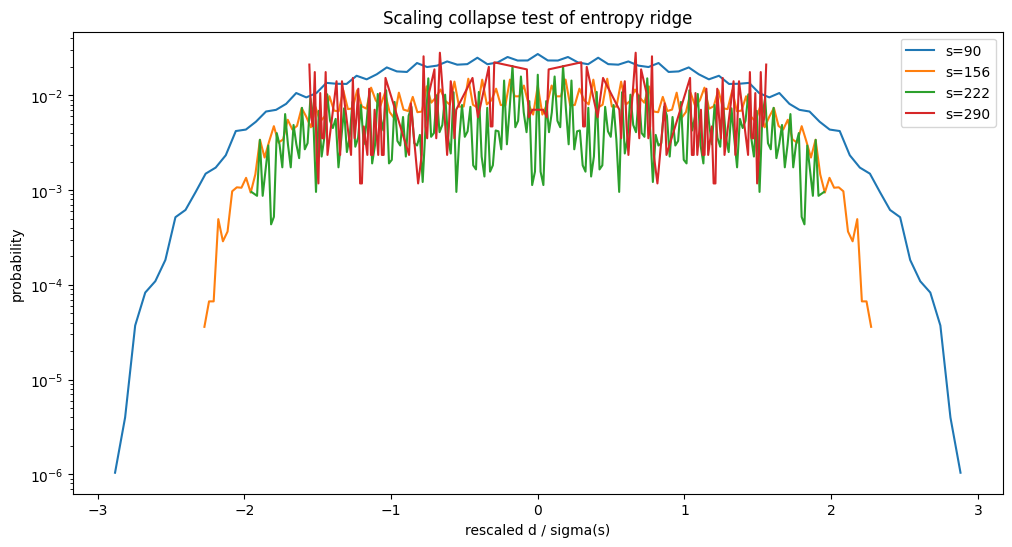

In [7]:
# =========================
# BUILD RESCALED DISTRIBUTIONS
# =========================

selected_s = df_width["s"].quantile([0.2, 0.4, 0.6, 0.8]).astype(int).values

plt.figure(figsize=(12, 6))

for s_val in selected_s:
    group = df_sd[df_sd["s"] == s_val]

    d = group["d"].to_numpy()
    w = group["count"].to_numpy()

    # normalize weights
    w = w / w.sum()

    # rescale
    std = df_width.loc[df_width["s"] == s_val, "d_std"].values[0]
    x = d / std

    # sort for plotting
    idx = np.argsort(x)
    x = x[idx]
    w = w[idx]

    plt.plot(x, w, label=f"s={s_val}")

plt.xlabel("rescaled d / sigma(s)")
plt.ylabel("probability")
plt.title("Scaling collapse test of entropy ridge")
plt.legend()
plt.yscale("log")
plt.show()

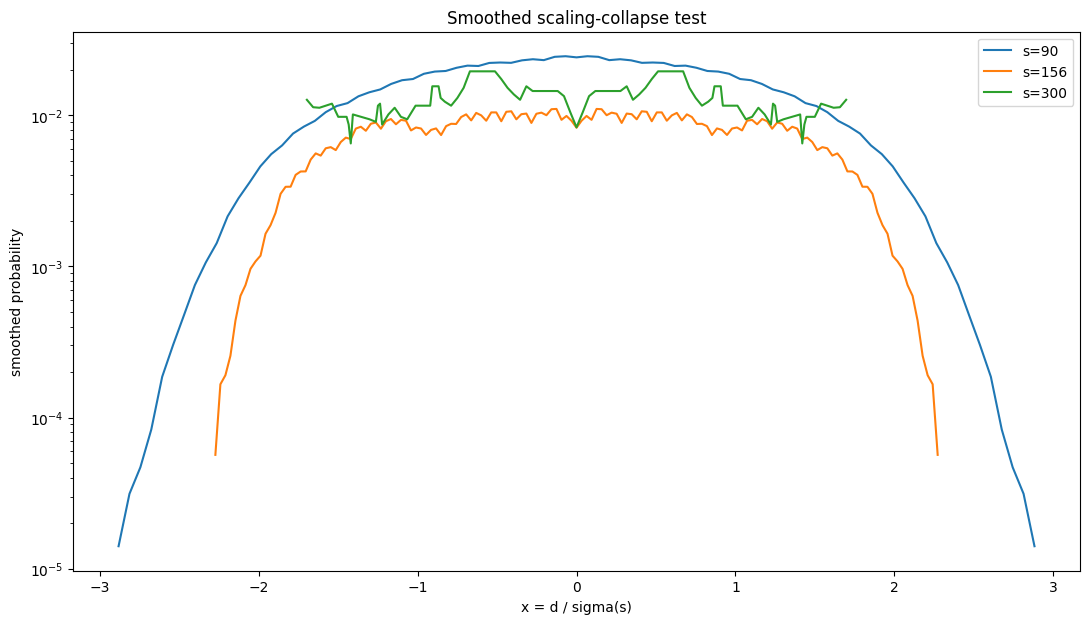

In [8]:
# =========================
# Pick a few representative s values
# =========================
selected_s = [90, 156, 300, 500, 800]

plt.figure(figsize=(13, 7))

for s_val in selected_s:
    group = df_sd[df_sd["s"] == s_val].sort_values("d").copy()
    if len(group) == 0:
        continue

    d = group["d"].to_numpy(dtype=float)
    w = group["count"].to_numpy(dtype=float)
    w = w / w.sum()

    std = df_width.loc[df_width["s"] == s_val, "d_std"].values[0]
    x = d / std

    # simple smoothing by rolling average in probability space
    smooth_w = pd.Series(w).rolling(window=5, center=True, min_periods=1).mean().to_numpy()

    plt.plot(x, smooth_w, label=f"s={s_val}")

plt.xlabel("x = d / sigma(s)")
plt.ylabel("smoothed probability")
plt.title("Smoothed scaling-collapse test")
plt.legend()
plt.yscale("log")
plt.show()

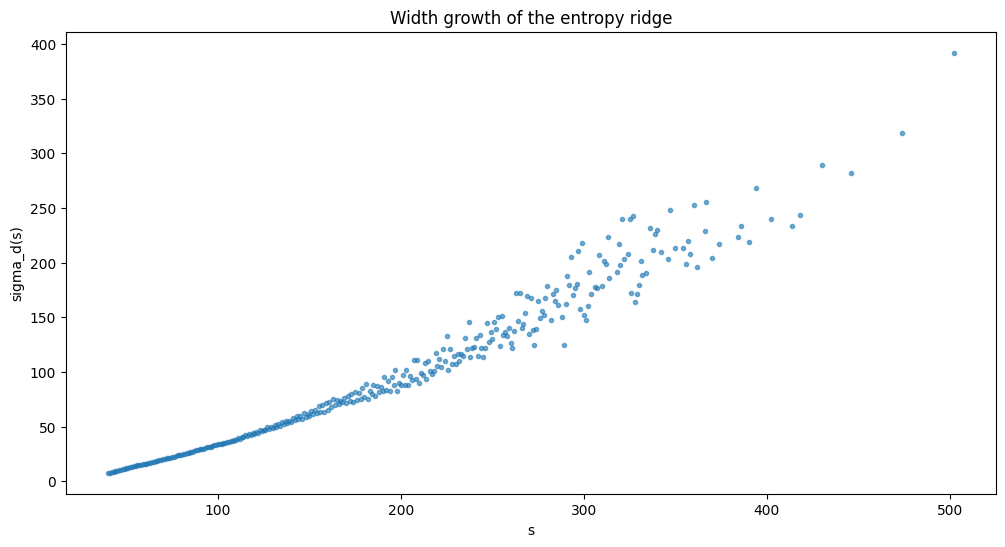

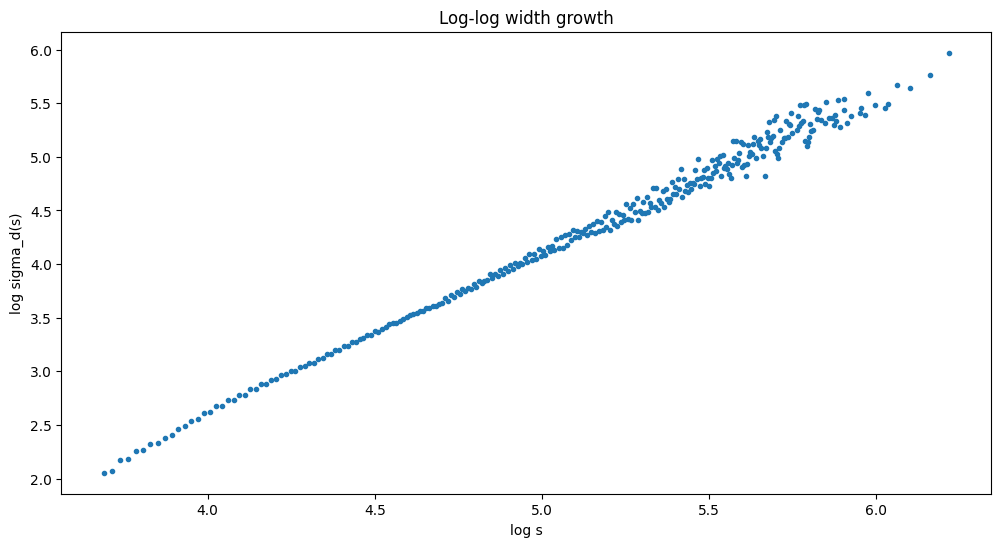

Power-law fit: sigma(s) ≈ 0.0344 * s^1.4941


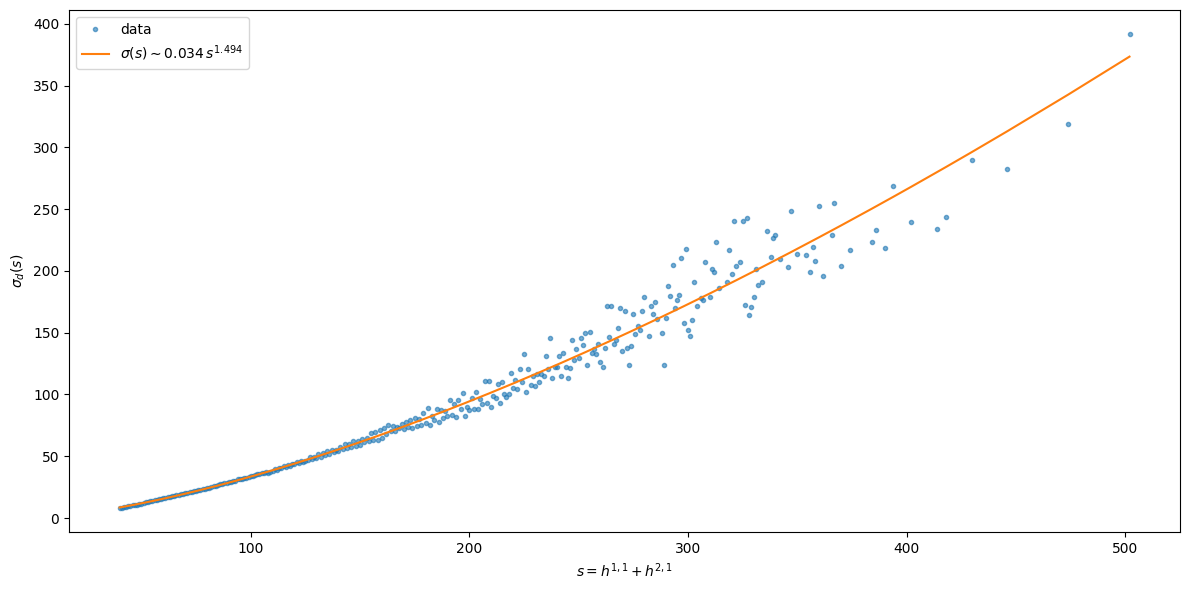

In [11]:
# avoid tiny-s regime
df_fit = df_width[df_width["s"] >= 40].copy()

x = df_fit["s"].to_numpy(dtype=float)
y = df_fit["d_std"].to_numpy(dtype=float)

plt.figure(figsize=(12, 6))
plt.plot(x, y, ".", alpha=0.6)
plt.xlabel("s")
plt.ylabel("sigma_d(s)")
plt.title("Width growth of the entropy ridge")
plt.show()

# log-log
plt.figure(figsize=(12, 6))
plt.plot(np.log(x), np.log(y), ".")
plt.xlabel("log s")
plt.ylabel("log sigma_d(s)")
plt.title("Log-log width growth")
plt.show()

# fit power law: sigma ~ a * s^alpha
alpha, log_a = np.polyfit(np.log(x), np.log(y), 1)
a = np.exp(log_a)

print(f"Power-law fit: sigma(s) ≈ {a:.4f} * s^{alpha:.4f}")

# compare fit visually
y_fit = a * x**alpha

plt.figure(figsize=(12, 6))
plt.plot(x, y, ".", label="data", alpha=0.6)
plt.plot(x, y_fit, label=rf"$\sigma(s) \sim {a:.3f}\, s^{{{alpha:.3f}}}$")
plt.xlabel(r"$s = h^{1,1} + h^{2,1}$")
plt.ylabel(r"$\sigma_d(s)$")
plt.legend()
plt.tight_layout()
plt.savefig("ridge_width_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

,s_min,n_points,a,alpha
0,40,315,0.034438,1.494103
1,60,295,0.036446,1.483619
2,80,275,0.036115,1.485287
3,100,255,0.035893,1.486403
4,120,235,0.036663,1.482604
5,150,205,0.037363,1.479235
6,200,155,0.040553,1.465010
7,250,105,0.087543,1.332331
8,300,57,0.175304,1.213988


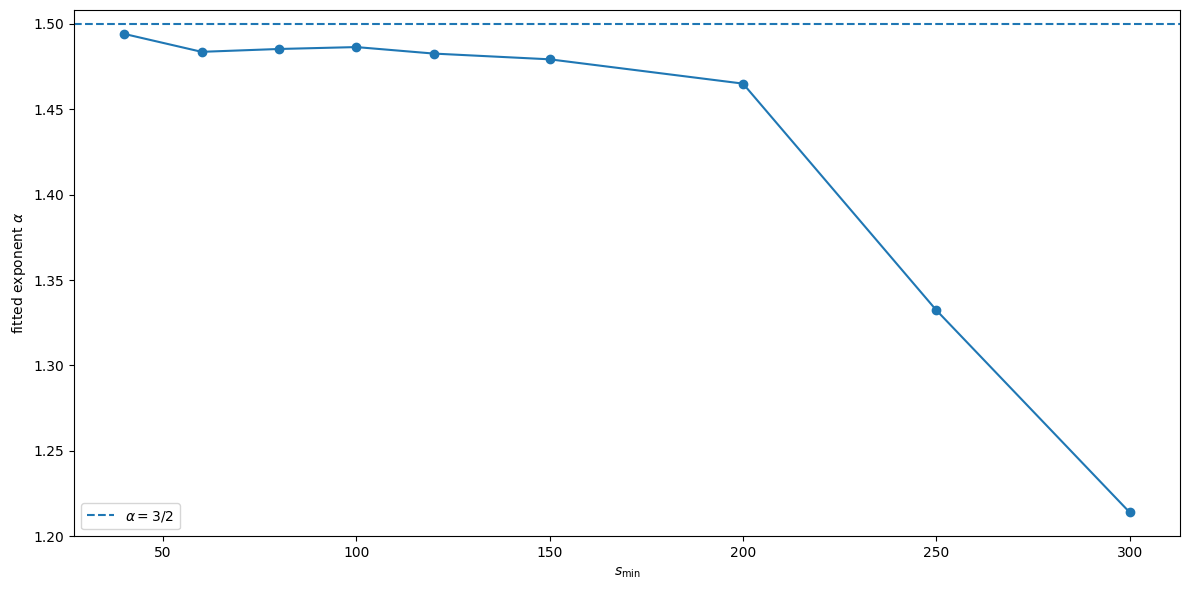

In [12]:
# Arbeitsbereich
df_fit = df_width[df_width["s"] >= 40].copy()

def fit_powerlaw(df_sub):
    x = df_sub["s"].to_numpy(dtype=float)
    y = df_sub["d_std"].to_numpy(dtype=float)
    alpha, log_a = np.polyfit(np.log(x), np.log(y), 1)
    a = np.exp(log_a)
    return a, alpha

# verschiedene Startschwellen testen
thresholds = [40, 60, 80, 100, 120, 150, 200, 250, 300]

rows = []
for smin in thresholds:
    sub = df_width[df_width["s"] >= smin].copy()
    if len(sub) < 20:
        continue
    a, alpha = fit_powerlaw(sub)
    rows.append((smin, len(sub), a, alpha))

df_alpha_scan = pd.DataFrame(rows, columns=["s_min", "n_points", "a", "alpha"])
display(df_alpha_scan)

plt.figure(figsize=(12, 6))
plt.plot(df_alpha_scan["s_min"], df_alpha_scan["alpha"], marker="o")
plt.axhline(1.5, linestyle="--", label=r"$\alpha = 3/2$")
plt.xlabel(r"$s_{\min}$")
plt.ylabel(r"fitted exponent $\alpha$")
plt.legend()
plt.tight_layout()
plt.savefig("alpha_cutoff_scan.png", dpi=300, bbox_inches="tight")
plt.show()

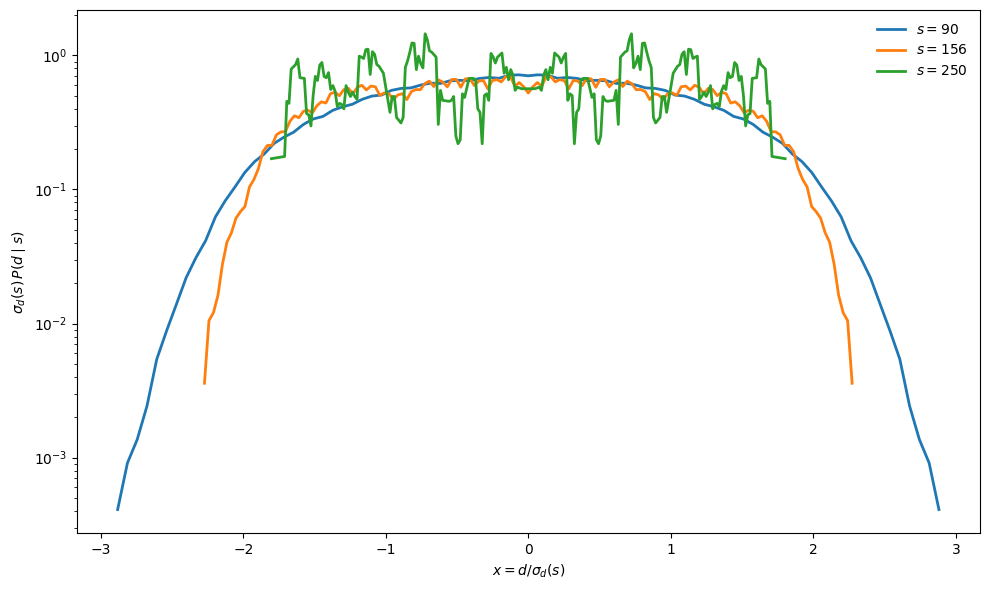

In [20]:
selected_s = [90, 156, 250, 400, 700, 1000]

plt.figure(figsize=(10, 6))

for s_val in selected_s:
    group = df_sd[df_sd["s"] == s_val].sort_values("d").copy()
    if len(group) == 0:
        continue

    d = group["d"].to_numpy(dtype=float)
    p = group["count"].to_numpy(dtype=float)
    p = p / p.sum()

    std = df_width.loc[df_width["s"] == s_val, "d_std"].values[0]
    x = d / std

    # rescaled density
    y = p * std

    # smoothing (wichtig für Paper!)
    smooth_y = pd.Series(y).rolling(window=5, center=True, min_periods=1).mean().to_numpy()

    idx = np.argsort(x)
    plt.plot(x[idx], smooth_y[idx], linewidth=2, label=f"$s={s_val}$")

plt.xlabel(r"$x = d / \sigma_d(s)$")
plt.ylabel(r"$\sigma_d(s)\, P(d \mid s)$")

plt.yscale("log")
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("collapse_sd.png", dpi=300, bbox_inches="tight")
plt.show()

Selected vertex_count values: [16, 15, 17, 14, 18, 13]


,vertex_count,s,total_count,d_mean,d_std,d_mode,support_size
0,16,32,66.0,-2.727273,3.087342,0.0,7
1,16,33,308.0,-3.363636,4.171359,-3.0,13
2,16,34,2555.0,-2.058708,4.171058,0.0,14
3,16,35,7388.0,-1.292907,4.346743,-3.0,14
4,16,36,35811.0,-1.649549,4.928456,0.0,17


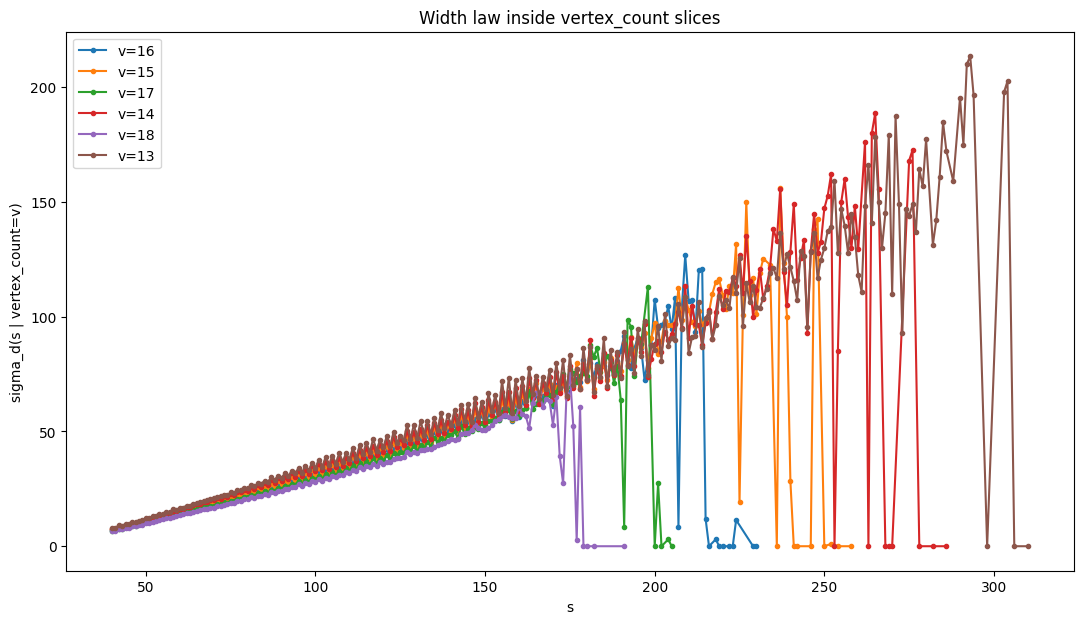

,vertex_count,n_points,a,alpha
0,16,160,0.031844,1.491785
1,15,181,0.033087,1.491490
2,17,144,0.026961,1.520690
3,14,203,0.037463,1.471621
4,18,125,0.027929,1.502330
5,13,228,0.044627,1.440769


In [22]:
# =========================
# Pick the most populated vertex_count slices
# =========================
top_v = (
    df_v.sort_values("count", ascending=False)
        .head(6)["vertex_count"]
        .tolist()
)

print("Selected vertex_count values:", top_v)

# =========================
# For each v: compute width law sigma_v(s)
# =========================
rows = []

for v in top_v:
    sub = df_vsd[df_vsd["vertex_count"] == v].copy()
    if len(sub) == 0:
        continue

    for s_val, group in sub.groupby("s"):
        d = group["d"].to_numpy(dtype=float)
        w = group["count"].to_numpy(dtype=float)

        wsum = w.sum()
        mean = (w * d).sum() / wsum
        var = (w * (d - mean)**2).sum() / wsum
        std = np.sqrt(var)

        i = np.argmax(w)
        d_mode = d[i]

        rows.append((v, s_val, wsum, mean, std, d_mode, len(group)))

df_vwidth = pd.DataFrame(
    rows,
    columns=["vertex_count", "s", "total_count", "d_mean", "d_std", "d_mode", "support_size"]
)

display(df_vwidth.head())

# =========================
# Plot sigma_v(s) for each selected v
# =========================
plt.figure(figsize=(13, 7))

for v in top_v:
    sub = df_vwidth[(df_vwidth["vertex_count"] == v) & (df_vwidth["s"] >= 40)]
    if len(sub) < 10:
        continue
    plt.plot(sub["s"], sub["d_std"], marker=".", linestyle="-", label=f"v={v}")

plt.xlabel("s")
plt.ylabel("sigma_d(s | vertex_count=v)")
plt.title("Width law inside vertex_count slices")
plt.legend()
plt.show()

# =========================
# Fit power laws per v
# =========================
fit_rows = []

for v in top_v:
    sub = df_vwidth[(df_vwidth["vertex_count"] == v) & (df_vwidth["s"] >= 40)].copy()

    # entferne problematische Punkte
    sub = sub[(sub["d_std"] > 0) & np.isfinite(sub["d_std"])]

    if len(sub) < 10:
        continue

    x = sub["s"].to_numpy(dtype=float)
    y = sub["d_std"].to_numpy(dtype=float)

    # optional: nur Bereich nehmen, wo genug Daten sind
    # (verhindert Zittern am Rand)
    cutoff = np.percentile(x, 90)
    mask = x <= cutoff
    x = x[mask]
    y = y[mask]

    if len(x) < 5:
        continue

    alpha, log_a = np.polyfit(np.log(x), np.log(y), 1)
    a = np.exp(log_a)

    fit_rows.append((v, len(x), a, alpha))

df_vfits = pd.DataFrame(fit_rows, columns=["vertex_count", "n_points", "a", "alpha"])
display(df_vfits)